<a href="https://colab.research.google.com/github/VictorHugoTesti/-am-t4-s1a2026/blob/main/MultiNeuralCredit0616.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Random Forest | Digest Pickle [Fase 1 - credit_data]

## Importar dados Drive

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bibliotecas Python

In [3]:
!pip -q install plotly
!pip -q install yellowbrick

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_credit

In [5]:
import pickle

In [6]:
with open('/content/drive/MyDrive/Aprendizagem de Maquina/credit.pkt', 'rb') as f:
   X_credit_treinamento, Y_credit_treinamento, X_credit_teste, Y_credit_teste = pickle.load(f)

In [7]:
X_credit_treinamento.shape, Y_credit_teste.shape

((1700, 3), (300,))

In [8]:
X_credit_teste.shape, Y_credit_teste.shape

((300, 3), (300,))

In [9]:
from sklearn.ensemble import RandomForestClassifier

In [10]:
from warnings import warn
random_credit = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
random_credit.fit(X_credit_treinamento, Y_credit_treinamento)
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None, criterion="entropy", max_depth='auto',
                        min_impurity_decrease=0.0, min_samples_split=None,
                        min_samples_leaf=1, min_weight_fraction_leaf=0.0, n_estimators=10,
                        n_jobs=None, oob_score=False, random_state=0, verbose=0, warm_start=False)


RandomForestClassifier(criterion='entropy', max_depth='auto',
                       min_samples_split=None, n_estimators=10, random_state=0)

## Criando Base Provisória

In [11]:
previsoes_arvore = random_credit.predict(X_credit_teste)

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [13]:
accuracy_score(Y_credit_teste, previsoes_arvore)

0.9733333333333334

In [14]:
confusion_matrix(Y_credit_teste, previsoes_arvore)

array([[257,   3],
       [  5,  35]])

In [15]:
print(classification_report(Y_credit_teste, previsoes_arvore))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       260
           1       0.92      0.88      0.90        40

    accuracy                           0.97       300
   macro avg       0.95      0.93      0.94       300
weighted avg       0.97      0.97      0.97       300



In [16]:
from yellowbrick.classifier import ConfusionMatrix

0.9733333333333334

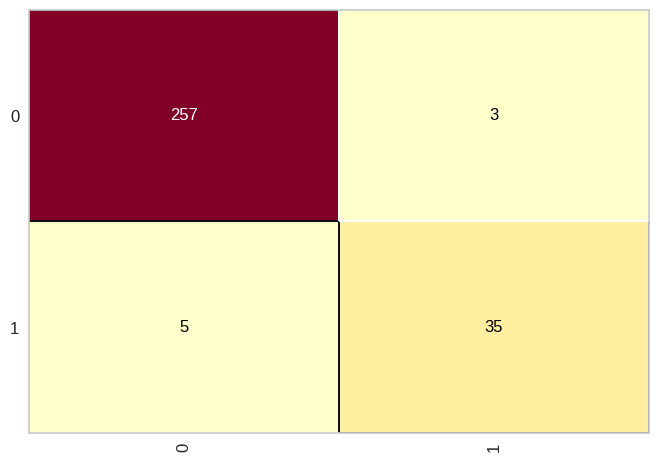

In [17]:
cm_credit = ConfusionMatrix(random_credit)
cm_credit.fit(X_credit_treinamento, Y_credit_treinamento)
cm_credit.score(X_credit_teste, Y_credit_teste)

# Pipeline Regressão | Digest [Fase 1 - credit_base]

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
regression_credit = LogisticRegression(random_state=1)
regression_credit.fit(X_credit_treinamento, Y_credit_treinamento)

LogisticRegression(random_state=1)

In [20]:
LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='12',
                   random_state=1, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

LogisticRegression(multi_class='auto', penalty='12', random_state=1)

In [21]:
regression_previsores = regression_credit.predict(X_credit_teste)
regression_previsores

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [22]:
accuracy_score(Y_credit_teste, regression_previsores)

0.9533333333333334

In [23]:
from yellowbrick.classifier import ConfusionMatrix

0.9533333333333334

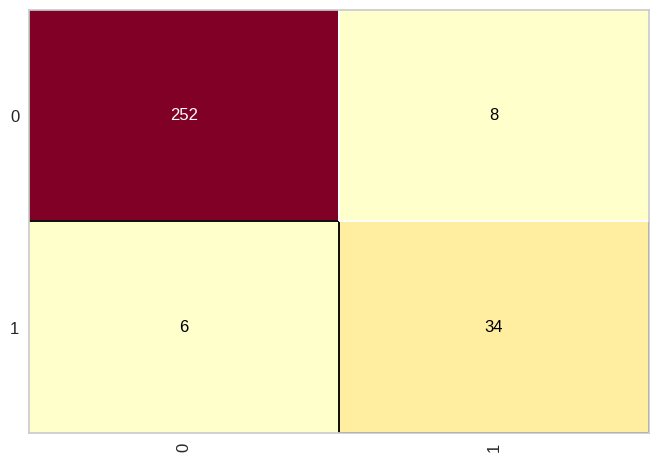

In [24]:
cm_credit = ConfusionMatrix(regression_credit)
cm_credit.fit(X_credit_treinamento, Y_credit_treinamento)
cm_credit.score(X_credit_teste, Y_credit_teste)

In [25]:
print(classification_report(Y_credit_teste, regression_previsores))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       260
           1       0.81      0.85      0.83        40

    accuracy                           0.95       300
   macro avg       0.89      0.91      0.90       300
weighted avg       0.95      0.95      0.95       300



# Pipeline SVM | Digest [Fase 1 - credit_base]

In [26]:
from sklearn.svm import SVC

In [27]:
svm_credit = SVC(kernel='rbf', random_state=1, C=2.0)
svm_credit.fit(X_credit_treinamento, Y_credit_treinamento)

SVC(C=2.0, random_state=1)

In [28]:
SVC(C=2.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=1, probability=False, random_state=1, shrinking=True, tol=0.001,
    verbose=False)

SVC(C=2.0, max_iter=1, random_state=1)

In [29]:
svc_previsores = svm_credit.predict(X_credit_teste)
svc_previsores

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [30]:
accuracy_score(Y_credit_teste, svc_previsores)

0.9933333333333333

0.9933333333333333

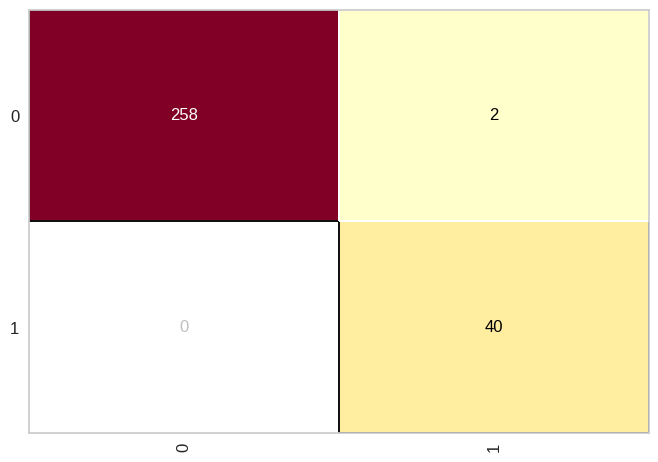

In [31]:
svm_cm = ConfusionMatrix(svm_credit)
svm_cm.fit(X_credit_treinamento, Y_credit_treinamento)
svm_cm.score(X_credit_teste, Y_credit_teste)

In [32]:
print(classification_report(Y_credit_teste, svc_previsores))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       260
           1       0.95      1.00      0.98        40

    accuracy                           0.99       300
   macro avg       0.98      1.00      0.99       300
weighted avg       0.99      0.99      0.99       300



# Pipeline Redes Neurais | Digest [Fase 1 - credit_base]

In [33]:
from sklearn.neural_network import MLPClassifier

In [34]:
redeneural_credit = MLPClassifier(verbose=True, max_iter=1000,
                                  tol=0.000010, solver='adam',
                                  hidden_layer_sizes=(100), activation='relu')
redeneural_credit.fit(X_credit_treinamento, Y_credit_treinamento)

Iteration 1, loss = 0.66084288
Iteration 2, loss = 0.59736841
Iteration 3, loss = 0.54016033
Iteration 4, loss = 0.49002611
Iteration 5, loss = 0.44600995
Iteration 6, loss = 0.40736595
Iteration 7, loss = 0.37370524
Iteration 8, loss = 0.34415259
Iteration 9, loss = 0.31854124
Iteration 10, loss = 0.29593167
Iteration 11, loss = 0.27606628
Iteration 12, loss = 0.25836117
Iteration 13, loss = 0.24250181
Iteration 14, loss = 0.22862834
Iteration 15, loss = 0.21609934
Iteration 16, loss = 0.20493219
Iteration 17, loss = 0.19476539
Iteration 18, loss = 0.18577810
Iteration 19, loss = 0.17742157
Iteration 20, loss = 0.16996513
Iteration 21, loss = 0.16283996
Iteration 22, loss = 0.15658737
Iteration 23, loss = 0.15077615
Iteration 24, loss = 0.14529466
Iteration 25, loss = 0.14033731
Iteration 26, loss = 0.13575588
Iteration 27, loss = 0.13160704
Iteration 28, loss = 0.12761551
Iteration 29, loss = 0.12390850
Iteration 30, loss = 0.12049783
Iteration 31, loss = 0.11738418
Iteration 32, los

MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [35]:
redeneural_credit.out_activation_

'logistic'

In [36]:
previsores_redeneural = redeneural_credit.predict(X_credit_teste)
previsores_redeneural

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [37]:
accuracy_score(Y_credit_teste, previsores_redeneural)

0.9933333333333333

0.9933333333333333

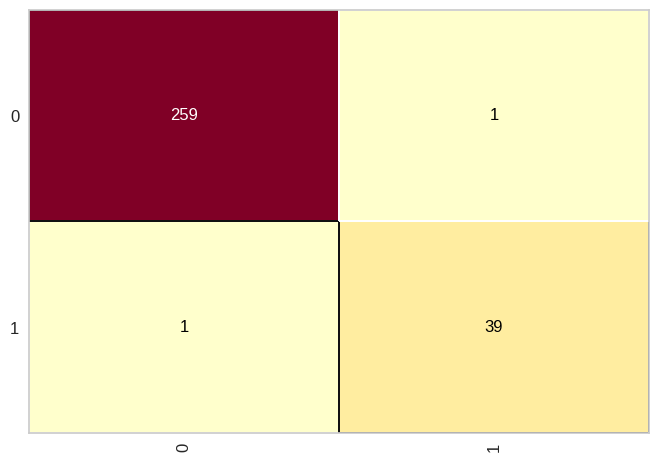

In [38]:
rm_credit = ConfusionMatrix(redeneural_credit)
rm_credit.fit(X_credit_treinamento, Y_credit_treinamento)
rm_credit.score(X_credit_teste, Y_credit_teste)

In [39]:
print(classification_report(Y_credit_teste, previsores_redeneural))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       260
           1       0.97      0.97      0.97        40

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



# Pipeline de Preparação de Dados | Digest [Fase 1 - credit_base]

In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [41]:
parametros = {'n_neighbors': [3, 5, 10, 20],
              'p':[1,2]}

In [42]:
grid_credit = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros)
grid_credit.fit(X_credit_treinamento, Y_credit_treinamento)
melhor_parametro_credit = grid_credit.best_params_
melhor_resultado_credit = grid_credit.best_score_

In [43]:
print(melhor_parametro_credit)
print(melhor_resultado_credit)

{'n_neighbors': 5, 'p': 2}
0.9823529411764707


# Pipeline de Orange | Regras [Fase 1 - credit_base]

In [44]:
!pip install Orange3

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.0/538.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.5/270.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.4/51.4 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.0/95.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 k

In [61]:
import Orange

In [62]:
base_orange_credit = Orange.data.Table('/content/drive/MyDrive/Aprendizagem de Maquina/credit_data_regras.csv')
base_orange_credit.domain

[income, age, loan | default]

In [63]:
credit_dividida = Orange.evaluation.testing.sample(base_orange_credit, n=0.25)
credit_dividida

([[61742.2, 44.8726, 8068.32 | 0],
  [46883.2, 30.3999, 6342.57 | 1],
  [39834.5, 63.3123, 699.956 | 0],
  [41285.4, 22.9111, 532.1 | 0],
  [57717.6, 48.7978, 3153.22 | 0],
  ...
 ],
 [[36594.8, 60.9126, 3492.33 | 0],
  [37087.3, 57.5763, 6391.15 | 0],
  [45930.5, 49.9913, 7765.25 | 0],
  [27089.4, 51.2942, 1851.31 | 0],
  [69992.3, 41.7712, 52.8722 | 0],
  ...
 ])

In [64]:
treinamento_credit = credit_dividida[1]
teste_credit = credit_dividida[0]

In [65]:
cn2_credit= Orange.classification.rules.CN2Learner()
regras_credit = cn2_credit(treinamento_credit)

In [66]:
for regras in regras_credit.rule_list:
  print(regras)

IF age>=34.9257164876908 THEN default=0 
IF loan>=7660.34617051509 THEN default=1 
IF income>=58132.4712652713 THEN default=0 
IF loan<=2507.64970973955 AND income>=20145.9885970689 THEN default=0 
IF loan>=6016.61509078929 AND age>=26.854012909811 THEN default=1 
IF loan>=5785.88427485782 AND income>=56050.3025818616 THEN default=1 
IF income>=46024.1445619613 AND income>=50360.6787929311 THEN default=0 
IF loan>=5785.88427485782 THEN default=1 
IF income>=46024.1445619613 THEN default=0 
IF loan<=3716.2546852118 AND income>=29724.4768752716 THEN default=0 
IF loan>=5416.3577980789005 THEN default=1 
IF loan>=5299.2397193039005 THEN default=0 
IF loan>=4849.33378471958 THEN default=1 
IF income>=34145.7995516248 THEN default=0 
IF loan>=3052.5766906145695 AND age>=18.055874488782102 THEN default=1 
IF income>=22089.8374845274 THEN default=0 
IF income<=20258.538662456 THEN default=1 
IF income<=21412.3086119071 THEN default=1 
IF income<=21605.7250904851 THEN default=1 
IF TRUE THEN d

In [67]:
credit_preview = Orange.evaluation.testing.TestOnTestData(treinamento_credit, teste_credit, [lambda testdata: regras_credit])
credit_preview

In [68]:
Orange.evaluation.CA(credit_preview)

array([0.978])